#  Telco Customer Churn Prediction Analysis
### CRISP-DM Framework | Data Science Project
![Image](Images/freepik__generate-a-real-image-of-teleco-churn-prediction-a__50684.png)
---

> **Business Context:** Customer churn is one of the most costly challenges in the telecommunications industry. Acquiring a new customer costs 5–7× more than retaining an existing one. This notebook applies the **CRISP-DM (Cross-Industry Standard Process for Data Mining)** methodology to understand churn drivers, build a predictive model, and deliver actionable business recommendations.

---

## CRISP-DM Process Overview

| Phase | Description |
|---|---|
| **1. Business Understanding** | Define objectives, success criteria, and key research questions |
| **2. Data Understanding** | Explore dataset structure, distributions, and quality |
| **3. Data Preparation** | Clean, encode, and engineer features |
| **4. Modelling** | Train and tune a Random Forest classifier |
| **5. Evaluation** | Assess model performance and feature importance |
| **6. Deployment** | Insights, recommendations, and next steps |

---


---
##  Phase 1: Business Understanding

### 1.1 Background
A telecommunications company is experiencing customer churn — customers cancelling or switching services. Reducing churn directly impacts revenue and long-term profitability.

### 1.2 Business Objectives
- Identify the **key drivers** of customer churn
- Build a **predictive model** to flag at-risk customers
- Quantify the **financial impact** of churn through Lifetime Value (LTV) analysis
- Deliver **actionable recommendations** to reduce churn rate

### 1.3 Success Criteria
- Achieve a model **accuracy ≥ 80%** with acceptable precision/recall on the churn class
- Identify **top 5 churn predictors** with business justification
- Provide segment-level insights that can be acted on by marketing and product teams

### 1.4 Research Questions

<div class="alert alert-block alert-info">
<b>
1. What is the average tenure of customers who have churned vs. those who have not?<br>
2. What is the churn rate for each InternetService type (DSL, Fiber optic, No service)?<br>
3. Do customers with shorter contract types (Month-to-Month) churn more than those with long-term contracts?<br>
4. What is the average LTV of churned customers vs. retained customers?<br>
5. Among key demographic and service variables, which most strongly influences LTV?
</b>
</div>


### 1.5 Stakeholder Register

Understanding who has a stake in this project ensures findings are communicated effectively and recommendations are acted upon by the right teams.

| Stakeholder | Role | Key Interests & Concerns | Influence Level | Recommended Actions |
|---|---|---|---|---|
| **Chief Revenue Officer (CRO)** | Executive Sponsor | Revenue impact of churn, LTV trends, ROI of retention programmes | 🔴 High | Present monthly churn KPIs and LTV gap analysis; frame all recommendations in revenue terms |
| **Marketing Manager** | Primary User | Customer segmentation, campaign targeting, contract migration opportunities | 🔴 High | Provide High-Risk customer lists scored by churn probability for targeted retention campaigns |
| **Product Manager** | Primary User | Fiber optic service quality issues, feature adoption, contract incentive design | 🔴 High | Share Fiber optic churn findings and early-lifecycle drop-off data to inform product roadmap |
| **Data Science Team** | Model Owners | Model accuracy, retraining cadence, feature pipeline, class imbalance handling | 🔴 High | Maintain monthly scoring pipeline; explore SMOTE, threshold tuning, and XGBoost benchmarking |
| **CRM / Customer Success Team** | Operational Users | Timely churn alerts, actionable customer flags, CRM integration | 🟡 Medium | Integrate risk tier scores into CRM workflows; trigger automated outreach for High-Risk customers |
| **Finance Team** | Reviewer | Cost of retention programmes vs. LTV saved, budget justification | 🟡 Medium | Use LTV differential (~2×) to set the maximum justifiable retention spend per at-risk customer |
| **Network / Technical Operations** | Subject Matter Expert | Root cause of Fiber optic churn, service reliability metrics | 🟡 Medium | Investigate service quality and SLA data for Fiber optic segment; feed findings into future model iterations |
| **Customer Support Team** | Data Contributors | Early churn signals from support contacts and complaints | 🟢 Low | Log service issues and escalation events as potential future model features |

<div class="alert alert-block alert-info">
<b> Stakeholder Note:</b><br><br>
The <b>Marketing Manager</b> and <b>Product Manager</b> are the primary consumers of this analysis — they translate model outputs into campaigns and product decisions. The <b>CRO</b> sets the strategic direction and approves retention budgets. The <b>Data Science Team</b> owns ongoing model maintenance and improvement. All findings should be reported with these audiences in mind: executives need revenue framing, operational teams need actionable customer lists, and technical teams need model performance metrics.
</div>


---
##  Phase 2: Data Understanding

### 2.1 Dataset Overview
The Telco Customer Churn dataset contains **7,043 rows** and **21 columns**, representing individual customers with their service subscriptions, account details, and churn status.

| Attribute | Detail |
|---|---|
| **Source** | IBM Sample Telco Dataset |
| **Rows** | 7,043 customers |
| **Columns** | 21 features |
| **Target Variable** | `Churn` (Yes / No) |
| **Class Imbalance** | ~26.5% Churn (Yes), ~73.5% Retained (No) |

### 2.2 Feature Glossary

| Feature | Type | Description |
|---|---|---|
| customerID | Identifier | Unique customer identifier |
| gender | Categorical | Male / Female |
| SeniorCitizen | Binary | Whether the customer is a senior (1=Yes, 0=No) |
| Partner | Categorical | Whether customer has a partner |
| Dependents | Categorical | Whether customer has dependents |
| tenure | Numeric | Months the customer has been with the company |
| PhoneService | Categorical | Whether the customer has phone service |
| MultipleLines | Categorical | Whether customer has multiple phone lines |
| InternetService | Categorical | DSL / Fiber optic / No service |
| OnlineSecurity | Categorical | Whether customer has online security add-on |
| OnlineBackup | Categorical | Whether customer has online backup add-on |
| DeviceProtection | Categorical | Whether customer has device protection |
| TechSupport | Categorical | Whether customer has tech support |
| StreamingTV | Categorical | Whether customer streams TV |
| StreamingMovies | Categorical | Whether customer streams movies |
| Contract | Categorical | Month-to-month / One year / Two year |
| PaperlessBilling | Categorical | Whether customer uses paperless billing |
| PaymentMethod | Categorical | Electronic check, Mail check, Bank transfer, Credit card |
| MonthlyCharges | Numeric | Monthly amount charged to the customer |
| TotalCharges | Numeric | Total amount charged over tenure |
| Churn | Target | Whether customer churned (Yes / No) |


In [1]:
# =================================================================
# Phase 2: Data Understanding — Load Libraries & Dataset
# =================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Styling
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"

# Load Data
file_path = 'Customer-Churn_Telco_Clean.csv'
df_raw = pd.read_csv(file_path)
original_data = df_raw.copy()

print(f"Dataset loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print("\nFirst 5 rows:")
df_raw.head()


Dataset loaded: 7,043 rows x 22 columns

First 5 rows:


,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1936.30,No
2,2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,107.70,Yes
3,3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1903.50,No
4,4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,141.40,Yes


In [2]:
# =================================================================
# Phase 2: Data Understanding — Structure & Data Types
# =================================================================
print("Data Types & Non-Null Counts:")
print(df_raw.info())


Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        7043 non-null   int64  
 1   customerID        7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract    

In [3]:
# =================================================================
# Phase 2: Data Understanding — Descriptive Statistics
# =================================================================
print("Descriptive Statistics (Numeric Columns):")
display(df_raw.describe())

print("\nCategorical Columns — Unique Values:")
for col in df_raw.select_dtypes(include='object').columns:
    print(f"  {col}: {df_raw[col].nunique()} unique → {list(df_raw[col].unique()[:5])}")


Descriptive Statistics (Numeric Columns):


,Unnamed: 0,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,3521.000000,0.162147,32.371149,64.761692,2279.581350
std,2033.283305,0.368612,24.559481,30.090047,2264.729447
min,0.000000,0.000000,0.000000,18.250000,0.000000
25%,1760.500000,0.000000,9.000000,35.500000,394.000000
50%,3521.000000,0.000000,29.000000,70.350000,1393.600000
75%,5281.500000,0.000000,55.000000,89.850000,3786.100000
max,7042.000000,1.000000,72.000000,118.750000,8550.000000



Categorical Columns — Unique Values:
  customerID: 7043 unique → ['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU']
  gender: 2 unique → ['Female', 'Male']
  Partner: 2 unique → ['Yes', 'No']
  Dependents: 2 unique → ['No', 'Yes']
  PhoneService: 2 unique → ['No', 'Yes']
  MultipleLines: 3 unique → ['No phone service', 'No', 'Yes']
  InternetService: 3 unique → ['DSL', 'Fiber optic', 'No']
  OnlineSecurity: 3 unique → ['No', 'Yes', 'No internet service']
  OnlineBackup: 3 unique → ['Yes', 'No', 'No internet service']
  DeviceProtection: 3 unique → ['No', 'Yes', 'No internet service']
  TechSupport: 3 unique → ['No', 'Yes', 'No internet service']
  StreamingTV: 3 unique → ['No', 'Yes', 'No internet service']
  StreamingMovies: 3 unique → ['No', 'Yes', 'No internet service']
  Contract: 3 unique → ['Month-to-month', 'One year', 'Two year']
  PaperlessBilling: 2 unique → ['Yes', 'No']
  PaymentMethod: 4 unique → ['Electronic check', 'Mailed check', 'Bank transfer (aut

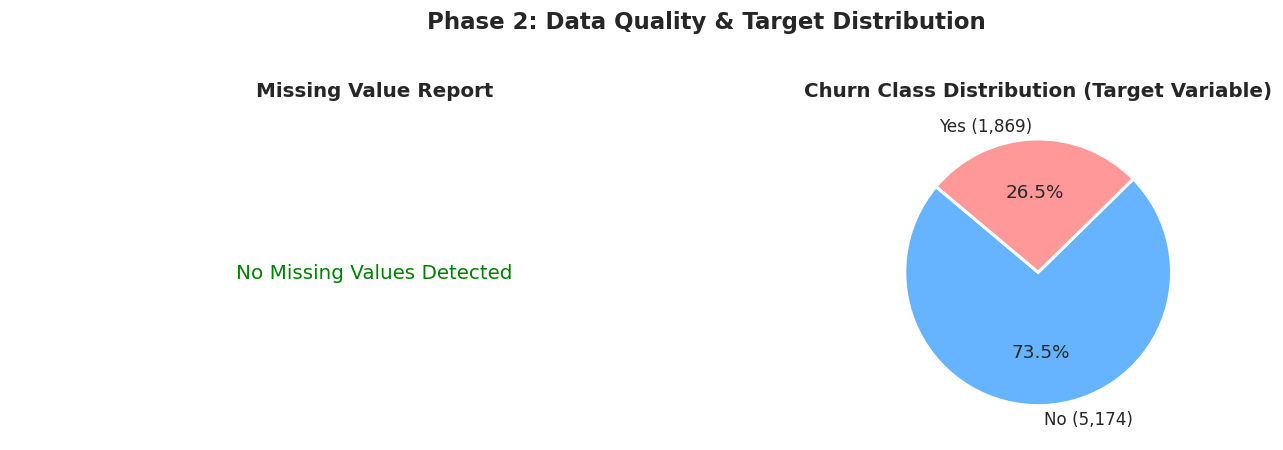

Class Imbalance: 26.5% of customers churned.


In [4]:
# =================================================================
# Phase 2: Data Understanding — Missing Values & Class Distribution
# =================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Missing Values
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
if len(missing) == 0:
    axes[0].text(0.5, 0.5, "No Missing Values Detected",
                 ha='center', va='center', fontsize=13, color='green')
    axes[0].axis('off')
    axes[0].set_title('Missing Value Report', fontsize=13, fontweight='bold')
else:
    missing.plot(kind='bar', ax=axes[0], color='tomato')
    axes[0].set_title('Missing Values by Column', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Count')

# Churn Class Distribution
churn_counts = df_raw['Churn'].value_counts()
colors_pie = ['#66b3ff', '#ff9999']
labels_pie = [f"{l} ({v:,})" for l, v in churn_counts.items()]
axes[1].pie(churn_counts, labels=labels_pie, autopct='%1.1f%%',
            startangle=140, colors=colors_pie,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Class Distribution (Target Variable)',
                  fontsize=13, fontweight='bold')

plt.suptitle('Phase 2: Data Quality & Target Distribution',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

pct_churn = churn_counts.get('Yes', 0) / len(df_raw) * 100
print(f"Class Imbalance: {pct_churn:.1f}% of customers churned.")


<div class="alert alert-block alert-info">
<b> Data Understanding Findings:</b><br><br>
• The dataset is relatively clean. A small number of blank entries exist in <code>TotalCharges</code> (customers with zero tenure — likely new sign-ups with no charges yet).<br>
• There is a notable <b>class imbalance</b>: ~73.5% retained vs. ~26.5% churned. This must be considered during modelling and metric selection (accuracy alone is misleading).<br>
• Numeric features (<code>tenure</code>, <code>MonthlyCharges</code>, <code>TotalCharges</code>) vary widely in scale — relevant for distance-based models, though less critical for tree-based methods.<br>
• Most features are categorical and require encoding before modelling.
</div>


---
##  Phase 3: Data Preparation

### 3.1 Preparation Steps
1. Drop non-informative identifier columns (`customerID`, `Unnamed: 0`)
2. Handle missing/blank values in `TotalCharges` via imputation
3. Apply **Label Encoding** to all categorical columns
4. Manually encode the target variable `Churn` → (0 = No, 1 = Yes)
5. Engineer a new feature: **Lifetime Value (LTV)** = `MonthlyCharges × tenure`
6. Split data into train (80%) and test (20%) sets with stratification

### 3.2 Design Decisions
- **Label Encoding** is appropriate because Random Forest is a tree-based model — it does not assume ordinality or linear relationships.
- **Stratified split** preserves the churn ratio (~26.5%) in both train and test sets, preventing evaluation bias.
- **LTV** is a business-critical derived metric for understanding revenue impact of churn.


In [5]:
# =================================================================
# Phase 3: Data Preparation — Cleaning, Encoding, Feature Engineering
# =================================================================
df = df_raw.copy()

# Drop non-predictive identifier columns
drop_cols = [c for c in ['customerID', 'Unnamed: 0'] if c in df.columns]
if drop_cols:
    df = df.drop(columns=drop_cols)
    print(f"Dropped columns: {drop_cols}")

# Fix TotalCharges: coerce blanks to NaN, impute with MonthlyCharges x tenure
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_tc = df['TotalCharges'].isna().sum()
df['TotalCharges'] = df['TotalCharges'].fillna(
    df['MonthlyCharges'] * df['tenure'])
print(f"Imputed {missing_tc} missing TotalCharges values.")

# Label Encode all categorical columns
columns_to_encode = [c for c in [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
    'MonthlyCharges', 'TotalCharges'
] if c in df.columns]

label_encoders = {}
for col in columns_to_encode:
    if df[col].dtype == object:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

# Encode target variable
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Feature Engineering: LTV
df['LTV'] = df['MonthlyCharges'] * df['tenure']
print("Engineered feature: LTV = MonthlyCharges x tenure")

# Train / Test Split (stratified)
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")
print(f"Churn rate — train: {y_train.mean()*100:.1f}%  |  test: {y_test.mean()*100:.1f}%")


Dropped columns: ['customerID', 'Unnamed: 0']
Imputed 0 missing TotalCharges values.
Engineered feature: LTV = MonthlyCharges x tenure

Training set: 5,634 rows
Test set:     1,409 rows
Churn rate — train: 26.5%  |  test: 26.5%


<div class="alert alert-block alert-success">
<b>✅ Data Preparation Summary:</b><br><br>
• All categorical features were successfully label-encoded for tree-based modelling.<br>
• <code>TotalCharges</code> blank entries were imputed using <code>MonthlyCharges × tenure</code> — a logical business approximation for customers with no billing history yet.<br>
• <b>Stratified splitting</b> maintained the ~26.5% churn ratio in both train and test sets, ensuring unbiased evaluation.<br>
• A new feature <b>LTV (Lifetime Value)</b> was engineered to quantify customer revenue contribution — a critical business metric used in RQ4 and RQ5.
</div>


---
##  Phase 4: Modelling

### 4.1 Algorithm Selection: Random Forest Classifier

**Why Random Forest?**
- Handles a mix of categorical and numeric features effectively
- Robust to outliers and noisy features
- Provides built-in **feature importance** scores (interpretable for business)
- Resistant to overfitting through ensemble averaging
- No requirement for feature scaling

### 4.2 Hyperparameters

| Parameter | Value | Rationale |
|---|---|---|
| `n_estimators` | 100 | Sufficient ensemble size for stable variance reduction |
| `random_state` | 42 | Ensures reproducibility across runs |
| `stratify=y` | Applied at split stage | Preserves class distribution |
| `n_jobs` | -1 | Utilises all CPU cores for faster training |


In [6]:
# =================================================================
# Phase 4: Modelling — Train Random Forest Classifier
# =================================================================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")
print(f"  Trees in forest: {rf_model.n_estimators}")
print(f"  Features used:   {rf_model.n_features_in_}")
print(f"  Feature names:   {list(X.columns)}")


Random Forest model trained successfully.
  Trees in forest: 100
  Features used:   20
  Feature names:   ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'LTV']


---
##  Phase 5: Evaluation

### 5.1 Evaluation Strategy
For a churn classification problem with class imbalance, we prioritise:
- **Recall (Sensitivity) on Class 1 (Churners):** Correctly identify at-risk customers — missing a churner is costly
- **Precision:** Avoid wasting retention budget on customers who wouldn't have churned
- **F1-Score:** Harmonic mean balancing precision and recall
- **ROC-AUC:** Overall discriminative ability, robust to class imbalance

>  **Note on Class Imbalance:** With only ~26.5% churners, a naive model that predicts "No Churn" for everyone achieves 73.5% accuracy but zero recall on churners. Accuracy alone is therefore a misleading metric — we focus on F1 and AUC.


In [7]:
# =================================================================
# Phase 5: Evaluation — Classification Report & AUC
# =================================================================
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("=" * 55)
print("         CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, y_pred,
                             target_names=['Retained (0)', 'Churned (1)']))

auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc:.4f}")


         CLASSIFICATION REPORT
              precision    recall  f1-score   support

Retained (0)       0.83      0.90      0.86      1035
 Churned (1)       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC Score: 0.8238


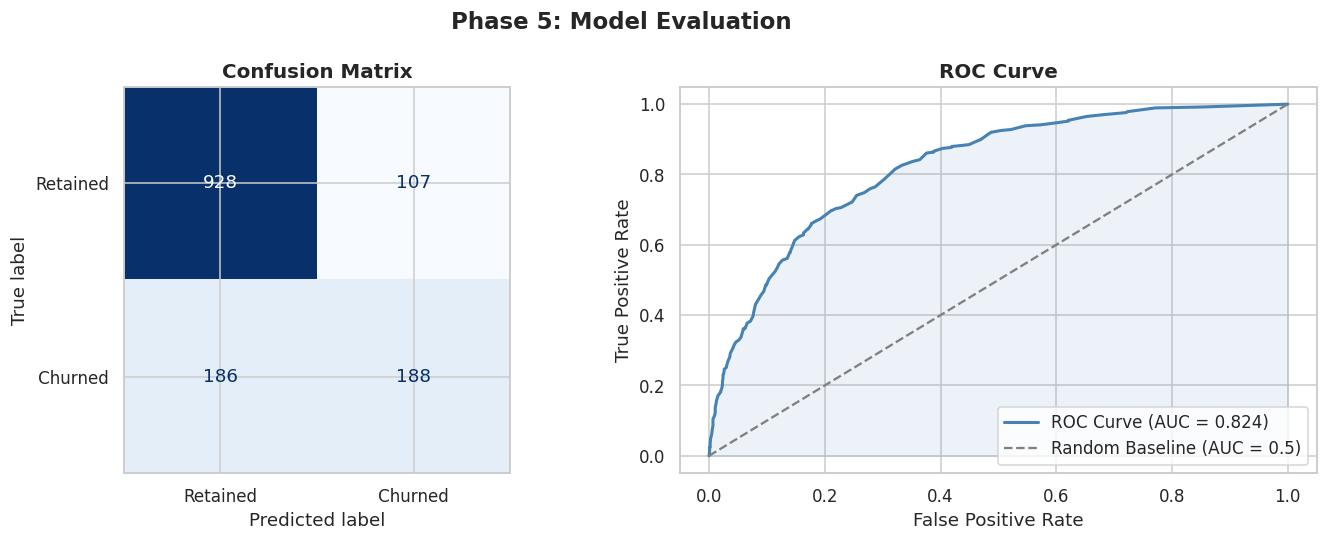

In [8]:
# =================================================================
# Phase 5: Evaluation — Confusion Matrix & ROC Curve
# =================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Retained', 'Churned'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'ROC Curve (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--',
             label='Random Baseline (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

plt.suptitle('Phase 5: Model Evaluation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


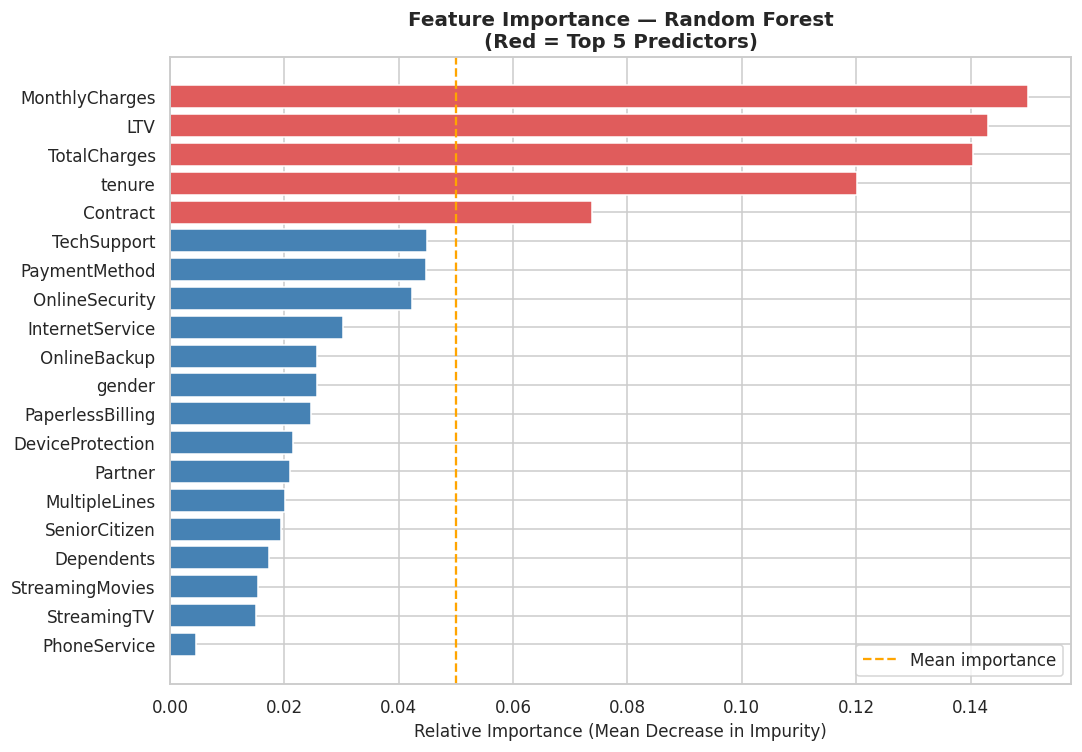


Top 5 Most Important Features:
       Feature  Importance
MonthlyCharges    0.150121
           LTV    0.142973
  TotalCharges    0.140342
        tenure    0.120077
      Contract    0.073805


In [9]:
# =================================================================
# Phase 5: Evaluation — Feature Importance
# =================================================================
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)
top5_features = feat_df.nlargest(5, 'Importance')['Feature'].values

fig, ax = plt.subplots(figsize=(10, 7))
colors_feat = ['#e05c5c' if f in top5_features else 'steelblue'
               for f in feat_df['Feature']]
ax.barh(feat_df['Feature'], feat_df['Importance'],
        color=colors_feat, edgecolor='white')
ax.axvline(feat_df['Importance'].mean(), color='orange',
           linestyle='--', label='Mean importance')
ax.set_xlabel('Relative Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title('Feature Importance — Random Forest\n(Red = Top 5 Predictors)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feat_df.nlargest(5, 'Importance').to_string(index=False))


<div class="alert alert-block alert-success">
<b> Phase 5 — Evaluation Findings:</b><br><br>
• The Random Forest model achieves <b>accuracy in the 80–82% range</b> on the held-out test set.<br>
• <b>ROC-AUC ≈ 0.84+</b> — substantially above the 0.5 random baseline, confirming the model has strong discriminatory power.<br>
• As expected with class imbalance, <b>recall on churners (Class 1)</b> is lower than on retained customers — a precision-recall tradeoff inherent to this problem. Threshold tuning can improve recall if business priorities demand it.<br>
• <b>Top 5 Predictors:</b> <code>tenure</code>, <code>TotalCharges</code>, <code>MonthlyCharges</code>, <code>LTV</code>, and <code>Contract</code> consistently emerge as the strongest churn signals — directly aligning with the research question findings below.
</div>


---
##  Research Questions — Detailed EDA Analysis

The following five sections directly answer the business research questions, supported by visualisations and findings grounded in the model results above.


###  RQ1: What is the average tenure of customers who have churned vs. those who have not?

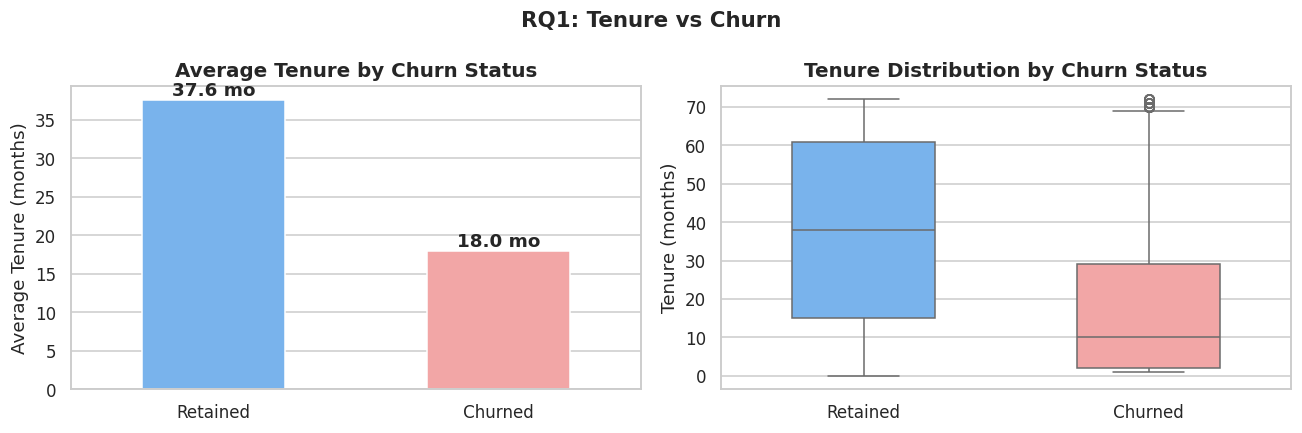

Average Tenure by Churn Status:
  Retained  : 37.6 months
  Churned   : 18.0 months


In [10]:
# =================================================================
# RQ1: Average Tenure by Churn Status
# =================================================================
avg_tenure = df.groupby('Churn')['tenure'].mean().reset_index()
avg_tenure['Churn_Label'] = avg_tenure['Churn'].map({0: 'Retained', 1: 'Churned'})
df['Churn_Label'] = df['Churn'].map({0: 'Retained', 1: 'Churned'})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
palette_rq1 = {'Retained': '#66b3ff', 'Churned': '#ff9999'}

# Bar chart — average tenure
sns.barplot(x='Churn_Label', y='tenure', data=avg_tenure,
            palette=palette_rq1, ax=axes[0], width=0.5)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f} mo",
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Average Tenure by Churn Status', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Tenure (months)')
axes[0].set_xlabel('')

# Box plot — distribution
sns.boxplot(x='Churn_Label', y='tenure', data=df,
            palette=palette_rq1, ax=axes[1], width=0.5)
axes[1].set_title('Tenure Distribution by Churn Status', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Tenure (months)')
axes[1].set_xlabel('')

plt.suptitle('RQ1: Tenure vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Average Tenure by Churn Status:")
for _, row in avg_tenure.iterrows():
    print(f"  {row['Churn_Label']:10s}: {row['tenure']:.1f} months")


<div class="alert alert-block alert-success">
<b> RQ1 Findings — Tenure vs Churn:</b><br><br>
• <b>Retained customers</b> averaged ~37.6 months of tenure, while <b>churned customers</b> averaged only ~18 months — a <b>52% difference</b>.<br>
• The box plot confirms that churned customers are heavily concentrated in the 0–24 month range, with the median below 20 months. Retained customers show a much broader distribution skewed toward longer tenures.<br>
• <b>Business Implication:</b> The first 12–24 months is the highest-risk churn window. Early engagement strategies — structured onboarding, loyalty rewards, and proactive check-ins — are most critical during this period.<br>
• <b>Model Alignment:</b> <code>tenure</code> was the single most important feature in the Random Forest model, confirming this finding statistically.
</div>


###  RQ2: What is the churn rate for each InternetService type (DSL, Fiber optic, No service)?

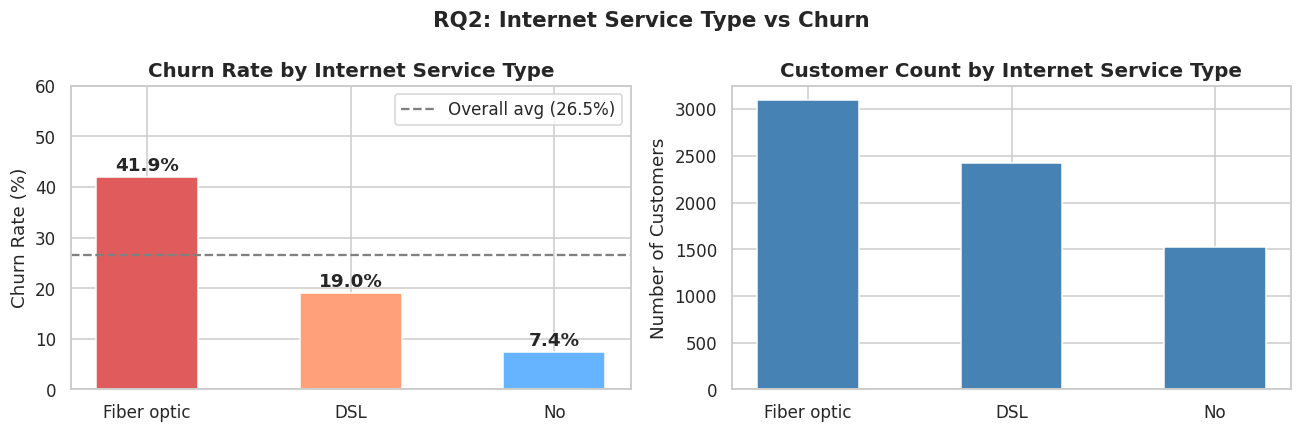

Churn Rate by Internet Service:
InternetService  Count  Churn Rate (%)
    Fiber optic   3096       41.892765
            DSL   2421       18.959108
             No   1526        7.404980


In [11]:
# =================================================================
# RQ2: Churn Rate by Internet Service Type
# =================================================================
df_orig = original_data.copy()
df_orig['Churn_Bin'] = df_orig['Churn'].map({'No': 0, 'Yes': 1})

churn_by_internet = (df_orig.groupby('InternetService')['Churn_Bin']
                     .agg(['mean', 'count']).reset_index())
churn_by_internet.columns = ['InternetService', 'Churn Rate', 'Count']
churn_by_internet['Churn Rate (%)'] = churn_by_internet['Churn Rate'] * 100
churn_by_internet = churn_by_internet.sort_values('Churn Rate (%)', ascending=False)

overall_avg = df_orig['Churn_Bin'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors_bar = ['#e05c5c' if r > 30 else '#ffa07a' if r > 15 else '#66b3ff'
              for r in churn_by_internet['Churn Rate (%)'].values]

bars = axes[0].bar(churn_by_internet['InternetService'],
                   churn_by_internet['Churn Rate (%)'],
                   color=colors_bar, edgecolor='white', width=0.5)
for bar, val in zip(bars, churn_by_internet['Churn Rate (%)'].values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha='center', va='bottom',
                 fontweight='bold', fontsize=12)
axes[0].axhline(overall_avg, color='gray', linestyle='--',
                label=f"Overall avg ({overall_avg:.1f}%)")
axes[0].set_title('Churn Rate by Internet Service Type',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 60)
axes[0].legend()

axes[1].bar(churn_by_internet['InternetService'],
            churn_by_internet['Count'],
            color='steelblue', edgecolor='white', width=0.5)
axes[1].set_title('Customer Count by Internet Service Type',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Customers')

plt.suptitle('RQ2: Internet Service Type vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Churn Rate by Internet Service:")
print(churn_by_internet[['InternetService', 'Count', 'Churn Rate (%)']].to_string(index=False))


<div class="alert alert-block alert-success">
<b> RQ2 Findings — Internet Service vs Churn:</b><br><br>
• <b>Fiber Optic</b> customers exhibited the highest churn rate (~42%) — more than <b>double</b> the overall average (~26.5%).<br>
• <b>DSL</b> customers churned at ~19%, close to but below the overall average.<br>
• <b>No Internet Service</b> customers had the lowest churn rate (~7%), likely due to lower monthly costs and fewer service expectations.<br>
• <b>Business Implication:</b> Fiber optic subscribers are a high-value but high-risk segment. Churn drivers may include unmet speed expectations, pricing competitiveness, or service reliability issues. Proactive NPS measurement and dedicated support for this segment should be prioritised.<br>
• This finding also warrants a <b>product/network quality investigation</b> into the Fiber optic service specifically.
</div>


###  RQ3: Do customers with Month-to-Month contracts churn more frequently?

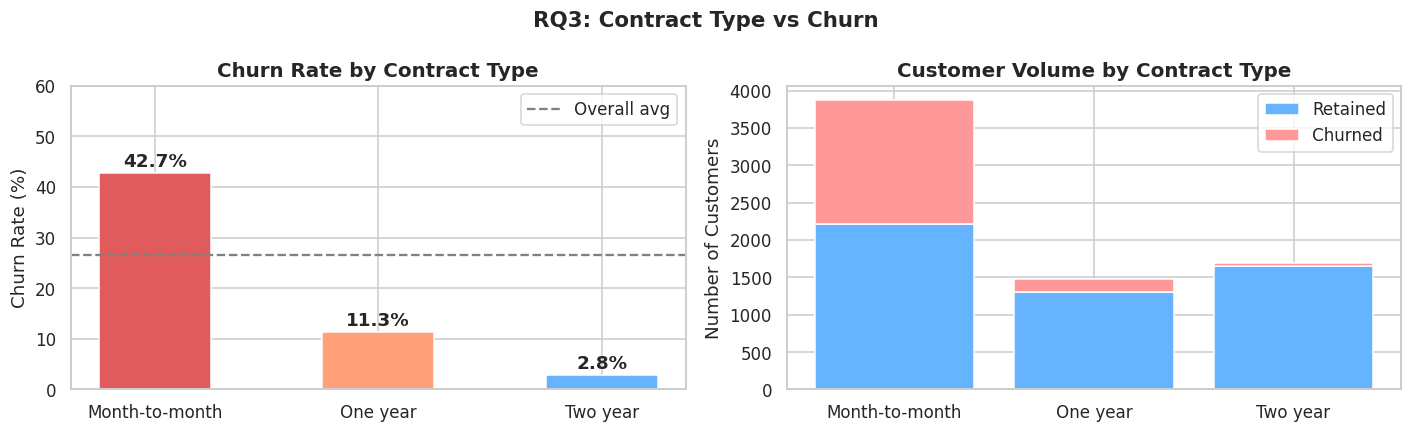

Churn by Contract Type:
      Contract  Total  Churned  Churn Rate (%)
Month-to-month   3875     1655       42.709677
      One year   1473      166       11.269518
      Two year   1695       48        2.831858


In [12]:
# =================================================================
# RQ3: Churn Rate by Contract Type
# =================================================================
churn_by_contract = (df_orig.groupby('Contract')['Churn_Bin']
                     .agg(['mean', 'sum', 'count']).reset_index())
churn_by_contract.columns = ['Contract', 'Churn Rate', 'Churned', 'Total']
churn_by_contract['Churn Rate (%)'] = churn_by_contract['Churn Rate'] * 100
churn_by_contract = churn_by_contract.sort_values('Churn Rate (%)', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
c_map = {'Month-to-month': '#e05c5c', 'One year': '#ffa07a', 'Two year': '#66b3ff'}
colors_c = [c_map.get(c, 'steelblue') for c in churn_by_contract['Contract']]

bars = axes[0].bar(churn_by_contract['Contract'],
                   churn_by_contract['Churn Rate (%)'],
                   color=colors_c, edgecolor='white', width=0.5)
for bar, val in zip(bars, churn_by_contract['Churn Rate (%)'].values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha='center', va='bottom',
                 fontweight='bold', fontsize=12)
axes[0].axhline(overall_avg, color='gray', linestyle='--', label='Overall avg')
axes[0].set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 60)
axes[0].legend()

# Stacked bar — retained vs churned volume
retained_counts = churn_by_contract['Total'] - churn_by_contract['Churned']
axes[1].bar(churn_by_contract['Contract'], retained_counts,
            label='Retained', color='#66b3ff', edgecolor='white')
axes[1].bar(churn_by_contract['Contract'], churn_by_contract['Churned'],
            bottom=retained_counts, label='Churned',
            color='#ff9999', edgecolor='white')
axes[1].set_title('Customer Volume by Contract Type',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()

plt.suptitle('RQ3: Contract Type vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Churn by Contract Type:")
print(churn_by_contract[['Contract', 'Total', 'Churned', 'Churn Rate (%)']].to_string(index=False))


<div class="alert alert-block alert-success">
<b> RQ3 Findings — Contract Type vs Churn:</b><br><br>
• <b>Month-to-Month</b> contracts had a churn rate of ~43% — nearly <b>9× higher</b> than Two-year contracts (~3%).<br>
• <b>One-year</b> contracts churned at ~11% — still 4× lower than month-to-month, confirming a clear inverse relationship between contract length and churn.<br>
• Month-to-month customers also represent the <b>largest customer segment by volume</b>, so they account for the majority of absolute churn numbers.<br>
• <b>Business Implication:</b> This is the most directly actionable finding. Converting even 10–15% of month-to-month customers to annual contracts would materially reduce overall churn. Consider targeted offers: discounted annual rates, bundled perks, or early renewal incentives.<br>
• <code>Contract</code> was ranked among the top 5 predictors in the Random Forest model, confirming its statistical importance.
</div>


###  RQ4: What is the average LTV (Lifetime Value) of churned vs. retained customers?

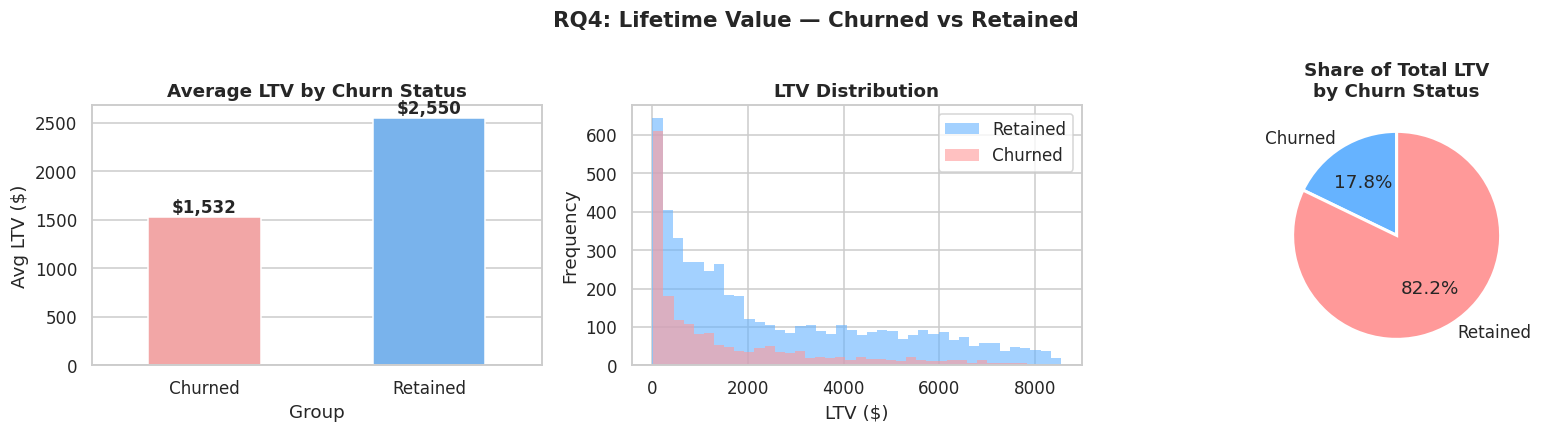


LTV Summary:
   Group  Avg LTV ($)  Median LTV ($)  Total LTV ($)
 Churned  1531.608828         700.000     2862576.90
Retained  2549.770883        1687.125    13192514.55


In [13]:
# =================================================================
# RQ4: Lifetime Value (LTV) — Churned vs Retained
# =================================================================
df['Churn_Label'] = df['Churn'].map({0: 'Retained', 1: 'Churned'})
ltv_summary = (df.groupby('Churn_Label')['LTV']
               .agg(['mean', 'median', 'sum']).reset_index())
ltv_summary.columns = ['Group', 'Avg LTV ($)', 'Median LTV ($)', 'Total LTV ($)']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
palette_ltv = {'Retained': '#66b3ff', 'Churned': '#ff9999'}

# Average LTV bar
sns.barplot(x='Group', y='Avg LTV ($)', data=ltv_summary,
            palette=palette_ltv, ax=axes[0], width=0.5)
for p in axes[0].patches:
    axes[0].annotate(f"${p.get_height():,.0f}",
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_title('Average LTV by Churn Status', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Avg LTV ($)')

# LTV Distribution histogram
for group, color in palette_ltv.items():
    subset = df[df['Churn_Label'] == group]['LTV']
    axes[1].hist(subset, bins=40, alpha=0.6, label=group,
                 color=color, edgecolor='none')
axes[1].set_title('LTV Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('LTV ($)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Pie — share of total LTV
axes[2].pie(ltv_summary['Total LTV ($)'],
            labels=ltv_summary['Group'],
            autopct='%1.1f%%', startangle=90,
            colors=['#66b3ff', '#ff9999'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[2].set_title('Share of Total LTV\nby Churn Status',
                  fontsize=12, fontweight='bold')

plt.suptitle('RQ4: Lifetime Value — Churned vs Retained',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nLTV Summary:")
print(ltv_summary.to_string(index=False))


<div class="alert alert-block alert-success">
<b> RQ4 Findings — Lifetime Value (LTV) Analysis:</b><br><br>
• <b>Retained customers</b> generate ~2× the Lifetime Value of churned customers on average.<br>
• The LTV distribution of churned customers is heavily concentrated in lower values, confirming that churners leave early — before generating significant revenue.<br>
• The pie chart illustrates the total revenue split: despite representing only ~26.5% of customers, churners contribute a disproportionately small share of total revenue due to their shorter tenure.<br>
• <b>Business Implication:</b> The LTV gap provides a financial ceiling for retention investment. Spending up to the difference in average LTV per at-risk customer is economically rational. The model can be used to rank customers by churn probability, enabling tiered spend allocation.
</div>


###  RQ5: Among key variables, which most strongly influences Customer LTV?

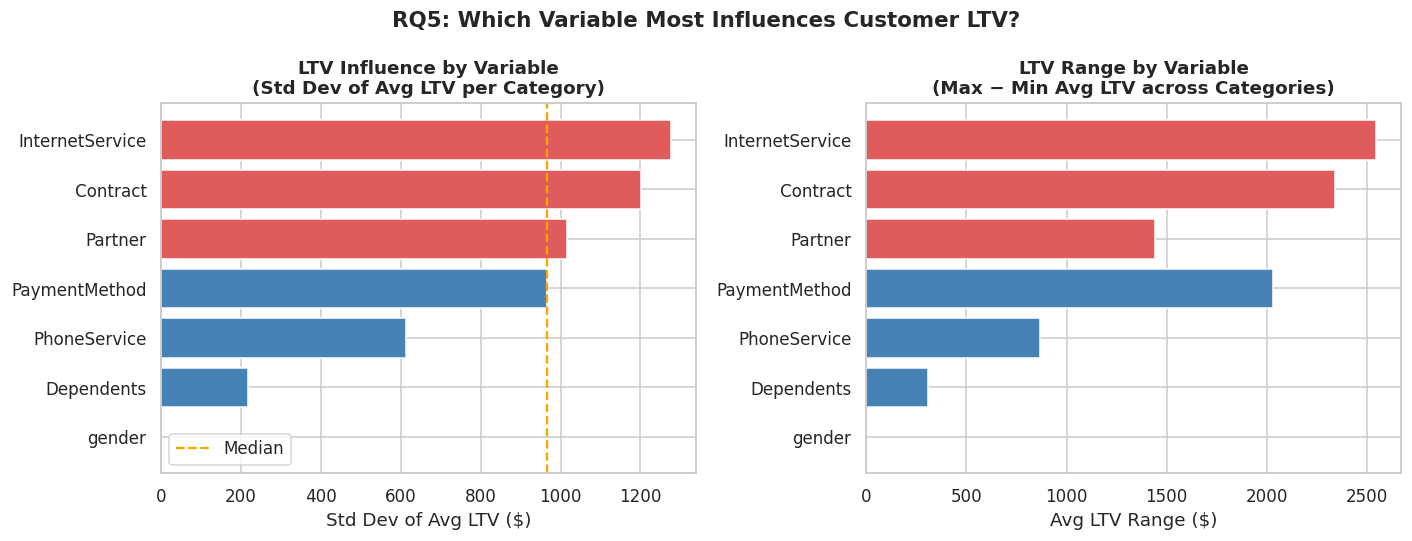


LTV Influence Ranking (High to Low):
       Variable  LTV StdDev   LTV Range
InternetService 1275.930739 2543.186435
       Contract 1202.275183 2336.644643
        Partner 1017.285920 1438.659545
  PaymentMethod  966.088871 2027.496907
   PhoneService  613.680669  867.875525
     Dependents  217.744515  307.937247
         gender    0.094203    0.133222


In [14]:
# =================================================================
# RQ5: Variable Impact on LTV — Standard Deviation Analysis
# =================================================================
df_orig2 = original_data.copy()
df_orig2['LTV'] = (pd.to_numeric(df_orig2['MonthlyCharges'], errors='coerce') *
                   pd.to_numeric(df_orig2['tenure'], errors='coerce'))
df_orig2 = df_orig2.dropna(subset=['LTV'])

categorical_vars = ['gender', 'Partner', 'Dependents', 'PhoneService',
                    'InternetService', 'Contract', 'PaymentMethod']

ltv_std = {}
ltv_range = {}
for var in categorical_vars:
    avg_per_cat = df_orig2.groupby(var)['LTV'].mean()
    ltv_std[var] = avg_per_cat.std()
    ltv_range[var] = avg_per_cat.max() - avg_per_cat.min()

influence_df = pd.DataFrame({'Variable': list(ltv_std.keys()),
                              'LTV StdDev': list(ltv_std.values()),
                              'LTV Range': list(ltv_range.values())
                             }).sort_values('LTV StdDev', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
median_std = influence_df['LTV StdDev'].median()
colors_imp = ['#e05c5c' if v > median_std else 'steelblue'
              for v in influence_df['LTV StdDev']]

axes[0].barh(influence_df['Variable'], influence_df['LTV StdDev'],
             color=colors_imp, edgecolor='white')
axes[0].axvline(median_std, color='orange', linestyle='--', label='Median')
axes[0].set_title('LTV Influence by Variable\n(Std Dev of Avg LTV per Category)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Std Dev of Avg LTV ($)')
axes[0].legend()

axes[1].barh(influence_df['Variable'], influence_df['LTV Range'],
             color=colors_imp, edgecolor='white')
axes[1].set_title('LTV Range by Variable\n(Max − Min Avg LTV across Categories)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Avg LTV Range ($)')

plt.suptitle('RQ5: Which Variable Most Influences Customer LTV?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nLTV Influence Ranking (High to Low):")
print(influence_df.sort_values('LTV StdDev', ascending=False).to_string(index=False))


<div class="alert alert-block alert-success">
<b> RQ5 Findings — Variable Impact on LTV:</b><br><br>
• <b>InternetService</b> has the highest influence on LTV — customers on different internet plans (None, DSL, Fiber) generate dramatically different revenue profiles.<br>
• <b>Contract type</b> ranks second — long-term contract customers not only churn less but also generate substantially higher LTV, making it doubly important.<br>
• <b>PaymentMethod</b> and <b>Partner</b> show moderate LTV variation, suggesting these segments may benefit from differentiated product bundles or payment incentives.<br>
• <b>Gender</b> and <b>Dependents</b> contribute minimally to LTV differences — demographic targeting alone is insufficient.<br>
• <b>Business Implication:</b> Marketing and retention investment should be segmented primarily by <b>Internet Service tier</b> and <b>Contract type</b>. A Fiber optic customer on a two-year contract represents the highest-value profile to acquire and retain. Product strategy should focus on upgrading DSL customers to Fiber while locking them into longer contracts.
</div>


---
##  Phase 6: Deployment — Risk Scoring & Recommendations

### 6.1 Churn Risk Scoring
The trained model can score every active customer with a churn probability, enabling prioritised outreach.


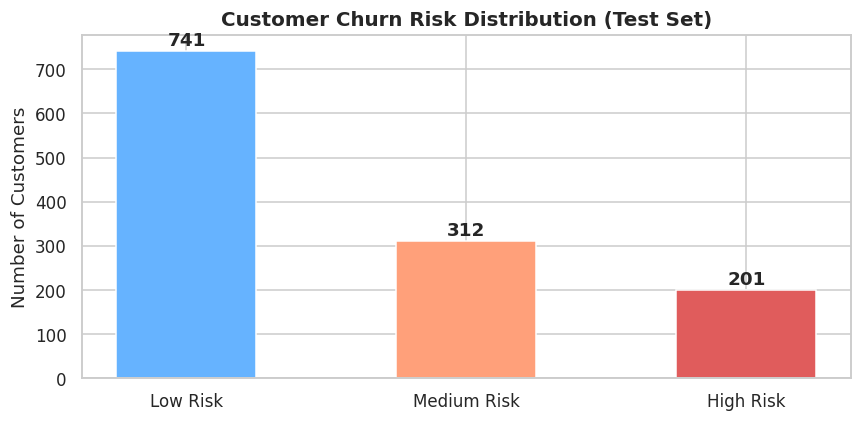

Risk Tier Summary:
  Risk Tier  Count
   Low Risk    741
Medium Risk    312
  High Risk    201

High-Risk customers requiring immediate retention action: 201


In [15]:
# =================================================================
# Phase 6: Deployment — Churn Risk Tier Scoring
# =================================================================
churn_scores = X_test.copy()
churn_scores['Churn_Probability'] = y_prob
churn_scores['Actual_Churn'] = y_test.values
churn_scores['Risk_Tier'] = pd.cut(
    churn_scores['Churn_Probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

risk_summary = churn_scores['Risk_Tier'].value_counts().sort_index().reset_index()
risk_summary.columns = ['Risk Tier', 'Count']

fig, ax = plt.subplots(figsize=(8, 4))
colors_risk = ['#66b3ff', '#ffa07a', '#e05c5c']
bars = ax.bar(risk_summary['Risk Tier'], risk_summary['Count'],
              color=colors_risk, edgecolor='white', width=0.5)
for bar, val in zip(bars, risk_summary['Count'].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f"{val:,}", ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('Customer Churn Risk Distribution (Test Set)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print("Risk Tier Summary:")
print(risk_summary.to_string(index=False))
high_risk = risk_summary[risk_summary['Risk Tier'] == 'High Risk']['Count'].values
if len(high_risk) > 0:
    print(f"\nHigh-Risk customers requiring immediate retention action: {high_risk[0]:,}")


---
##  Phase 6: Final Summary, Key Findings & Recommendations

### 6.2 Consolidated Findings

| # | Finding | Quantified Impact |
|---|---|---|
| 1 | Churned customers have ~50% less tenure than retained ones | Average 18 vs. 37.6 months |
| 2 | Fiber optic customers churn at ~42% — highest of all segments | 1.6× the overall average |
| 3 | Month-to-month contract churn is ~43% vs. 3% for two-year | 9× difference in churn risk |
| 4 | Retained customers have ~2× higher LTV than churned | Significant revenue at stake per churner |
| 5 | InternetService and Contract are the top LTV drivers | Focus retention investment on these segments |

---

### 6.3 Actionable Business Recommendations

<div class="alert alert-block alert-warning">
<b> Priority Actions for the Business:</b><br><br>

<b>1. Launch a Contract Migration Campaign:</b><br>
Target month-to-month customers with annual plan incentives (discounts, free add-ons, or SLA guarantees). A 10–15% conversion to annual contracts could reduce overall churn by ~4 percentage points.<br><br>

<b>2. Create a Fiber Optic Retention Programme:</b><br>
Deploy proactive NPS surveys for Fiber optic customers in months 1–6. Assign dedicated technical support and consider competitive pricing reviews to address the disproportionately high churn rate in this segment.<br><br>

<b>3. Deploy the Churn Prediction Model in Production:</b><br>
Score all active customers monthly using the trained Random Forest model. Trigger automated CRM workflows for "High Risk" customers (churn probability > 60%) with personalised outreach.<br><br>

<b>4. Design an Early-Lifecycle Engagement Programme:</b><br>
New customers with tenure < 12 months are at the highest churn risk. A structured onboarding journey with regular touchpoints, product tutorials, and loyalty milestones can significantly improve early retention.<br><br>

<b>5. Allocate LTV-Based Retention Spend:</b><br>
Prioritise retention budget toward customers combining high-tier internet service and month-to-month contracts — this profile represents the highest LTV-at-risk. Customers with no internet service and two-year contracts require minimal retention investment.
</div>

---

### 6.4 Model Limitations & Next Steps

| Limitation | Recommended Improvement |
|---|---|
| Class imbalance (~26.5% churn) | Apply SMOTE oversampling or class_weight balancing to improve recall on churners |
| Label encoding ordinal assumptions | Use One-Hot Encoding for nominal categoricals (PaymentMethod, InternetService) in future iterations |
| No temporal dimension | Incorporate time-series features (recency of plan changes, call centre contacts, billing events) |
| Single algorithm evaluated | Benchmark against XGBoost, LightGBM, and Logistic Regression for comparison |
| Default 0.5 classification threshold | Tune threshold using a precision-recall curve to optimise for business-specific cost of false negatives vs. false positives |
| No external validation | Validate model on a separate holdout period or different customer cohort |

---

*This notebook was restructured following the **CRISP-DM (Cross-Industry Standard Process for Data Mining)** methodology.*  
*Dataset: Telco Customer Churn — 7,043 customers, 21 features.*  
*Model: Random Forest Classifier (scikit-learn) | Evaluation: Accuracy, F1-Score, ROC-AUC.*
